In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load master dataset
df = pd.read_csv('../data/master_dataset.csv', parse_dates=['date'])
print(f"Shape: {df.shape}")
print(f"Range: {df['date'].min()} to {df['date'].max()}")
print(df.head())

Shape: (73, 10)
Range: 2019-12-01 00:00:00 to 2025-12-01 00:00:00
        date   tbill_91  tbill_182  tbill_364  policy_rate  us_tbill_3m  \
0 2019-12-01  14.690000  15.150000  17.880000         16.0     1.535238   
1 2020-01-01  14.703333  15.156667  17.833333         15.5     1.522381   
2 2020-02-01  14.716667  15.163333  17.786667         15.0     1.515263   
3 2020-03-01  14.730000  15.170000  17.740000         14.5     0.286364   
4 2020-04-01  14.050000  14.270000  16.760000         14.5     0.138095   

   fed_funds   usd_ghs  inflation           gdp  
0       1.55  5.674997    7.14364  6.835263e+10  
1       1.55  5.627445    9.88729  7.000824e+10  
2       1.58  5.354438    9.88729  7.000824e+10  
3       0.65  5.542257    9.88729  7.000824e+10  
4       0.05  5.730075    9.88729  7.000824e+10  


In [2]:
# ============================================================
# FEATURE GROUP 1: Technical / Statistical Features
# ============================================================

# Lag features (previous months' rates)
df['rate_lag_1'] = df['tbill_91'].shift(1)
df['rate_lag_2'] = df['tbill_91'].shift(2)
df['rate_lag_3'] = df['tbill_91'].shift(3)
df['rate_lag_4'] = df['tbill_91'].shift(4)

# Momentum (rate change over N months)
df['momentum_1m'] = df['tbill_91'] - df['tbill_91'].shift(1)
df['momentum_3m'] = df['tbill_91'] - df['tbill_91'].shift(3)
df['momentum_6m'] = df['tbill_91'] - df['tbill_91'].shift(6)

# Rate of change (percentage)
df['roc_1m'] = df['tbill_91'].pct_change(1) * 100
df['roc_3m'] = df['tbill_91'].pct_change(3) * 100

# Rate acceleration (is momentum increasing or decreasing?)
df['acceleration'] = df['momentum_1m'] - df['momentum_1m'].shift(1)

# Rolling statistics
df['rolling_mean_6m'] = df['tbill_91'].rolling(6).mean()
df['rolling_mean_12m'] = df['tbill_91'].rolling(12).mean()
df['rolling_std_6m'] = df['tbill_91'].rolling(6).std()
df['rolling_std_12m'] = df['tbill_91'].rolling(12).std()

# Mean reversion signal (z-score: how far from the 12-month average)
df['z_score_12m'] = (df['tbill_91'] - df['rolling_mean_12m']) / df['rolling_std_12m']

print("Technical features created:")
print(df[['date', 'tbill_91', 'rate_lag_1', 'momentum_1m', 'roc_1m', 
           'rolling_mean_6m', 'z_score_12m']].tail(10))

Technical features created:
         date  tbill_91  rate_lag_1  momentum_1m     roc_1m  rolling_mean_6m  \
63 2025-03-01     17.15       26.93        -9.78 -36.316376        25.478333   
64 2025-04-01     15.47       17.15        -1.68  -9.795918        23.756667   
65 2025-05-01     15.11       15.47        -0.36  -2.327085        21.793333   
66 2025-06-01     14.74       15.11        -0.37  -2.448709        19.628333   
67 2025-07-01     13.44       14.74        -1.30  -8.819539        17.140000   
68 2025-08-01     10.26       13.44        -3.18 -23.660714        14.361667   
69 2025-09-01     10.45       10.26         0.19   1.851852        13.245000   
70 2025-10-01     10.63       10.45         0.18   1.722488        12.438333   
71 2025-11-01     10.98       10.63         0.35   3.292568        11.750000   
72 2025-12-01     11.08       10.98         0.10   0.910747        11.140000   

    z_score_12m  
63    -2.876646  
64    -2.244441  
65    -1.767172  
66    -1.480798  
6

In [3]:
# ============================================================
# FEATURE GROUP 2: Yield Curve Features
# ============================================================

# Yield curve slope (long rate - short rate)
df['yield_slope'] = df['tbill_364'] - df['tbill_91']

# Yield curve curvature (is the middle rate above/below the average of short and long?)
df['yield_curvature'] = 2 * df['tbill_182'] - df['tbill_91'] - df['tbill_364']

# Spread between 182-day and 91-day
df['spread_182_91'] = df['tbill_182'] - df['tbill_91']

# Spread between 364-day and 182-day
df['spread_364_182'] = df['tbill_364'] - df['tbill_182']

print("Yield curve features:")
print(df[['date', 'tbill_91', 'tbill_182', 'tbill_364', 
           'yield_slope', 'yield_curvature', 'spread_182_91']].tail(10))

Yield curve features:
         date  tbill_91  tbill_182  tbill_364  yield_slope  yield_curvature  \
63 2025-03-01     17.15      18.48      19.85         2.70            -0.04   
64 2025-04-01     15.47      16.23      18.62         3.15            -1.63   
65 2025-05-01     15.11      15.68      16.64         1.53            -0.39   
66 2025-06-01     14.74      15.34      15.76         1.02             0.18   
67 2025-07-01     13.44      14.47      14.84         1.40             0.66   
68 2025-08-01     10.26      12.31      13.11         2.85             1.25   
69 2025-09-01     10.45      12.40      12.94         2.49             1.41   
70 2025-10-01     10.63      12.57      12.90         2.27             1.61   
71 2025-11-01     10.98      12.61      13.03         2.05             1.21   
72 2025-12-01     11.08      12.50      12.92         1.84             1.00   

    spread_182_91  
63           1.33  
64           0.76  
65           0.57  
66           0.60  
67      

In [4]:
# ============================================================
# FEATURE GROUP 3: Macro / Policy Features
# ============================================================

# Spread vs policy rate (monetary policy transmission)
df['policy_spread'] = df['tbill_91'] - df['policy_rate']

# Real rate (T-bill rate minus inflation)
df['real_rate'] = df['tbill_91'] - df['inflation']

# Ghana-US rate differential (capital flow signal)
df['rate_differential'] = df['tbill_91'] - df['us_tbill_3m']

# FX momentum (is the cedi weakening or strengthening?)
df['fx_change_1m'] = df['usd_ghs'].pct_change(1) * 100
df['fx_change_3m'] = df['usd_ghs'].pct_change(3) * 100

# Inflation momentum
df['inflation_change'] = df['inflation'] - df['inflation'].shift(1)

# Fed funds change (global monetary tightening/easing signal)
df['fed_change'] = df['fed_funds'] - df['fed_funds'].shift(1)

print("Macro features:")
print(df[['date', 'policy_spread', 'real_rate', 'rate_differential', 
           'fx_change_1m', 'inflation_change']].tail(10))

Macro features:
         date  policy_spread  real_rate  rate_differential  fx_change_1m  \
63 2025-03-01         -10.85  -5.698328          12.950476      0.100272   
64 2025-04-01         -12.53  -7.378328          11.260952     -0.344797   
65 2025-05-01         -12.89  -7.738328          10.862857    -19.902610   
66 2025-06-01         -13.26  -8.108328          10.506500    -16.964000   
67 2025-07-01         -11.56  -9.408328           9.192273      1.188917   
68 2025-08-01         -14.74 -12.588328           6.136190      3.362392   
69 2025-09-01         -11.05 -12.398328           6.532381     13.221679   
70 2025-10-01         -10.87 -12.218328           6.812273     -4.491040   
71 2025-11-01          -7.02 -11.868328           7.201111     -5.234080   
72 2025-12-01          -6.92 -11.768328           7.489545      3.628432   

    inflation_change  
63               0.0  
64               0.0  
65               0.0  
66               0.0  
67               0.0  
68       

In [5]:
# ============================================================
# FEATURE GROUP 4: Regime Features
# ============================================================

# Volatility regime (high/low based on rolling std)
vol_threshold = df['rolling_std_6m'].median()
df['high_vol_regime'] = (df['rolling_std_6m'] > vol_threshold).astype(int)

# Rate regime (rising/falling/stable)
df['rate_regime'] = pd.cut(
    df['momentum_3m'],
    bins=[-np.inf, -1, 1, np.inf],
    labels=['falling', 'stable', 'rising']
)

# Policy stance (is policy rate above or below T-bill rate?)
df['policy_tight'] = (df['policy_rate'] > df['tbill_91']).astype(int)

print("Regime features:")
print(df[['date', 'tbill_91', 'rolling_std_6m', 'high_vol_regime', 
           'rate_regime', 'policy_tight']].tail(10))

Regime features:
         date  tbill_91  rolling_std_6m  high_vol_regime rate_regime  \
63 2025-03-01     17.15        4.171246                1     falling   
64 2025-04-01     15.47        5.818504                1     falling   
65 2025-05-01     15.11        6.497599                1     falling   
66 2025-06-01     14.74        6.284522                1     falling   
67 2025-07-01     13.44        4.943764                1     falling   
68 2025-08-01     10.26        2.340063                1     falling   
69 2025-09-01     10.45        2.341971                1     falling   
70 2025-10-01     10.63        2.254218                1     falling   
71 2025-11-01     10.98        1.873692                1      stable   
72 2025-12-01     11.08        1.168743                0      stable   

    policy_tight  
63             1  
64             1  
65             1  
66             1  
67             1  
68             1  
69             1  
70             1  
71             1  


In [7]:
# ============================================================
# FEATURE GROUP 5: Target Variable
# ============================================================

# What I want to predict: next month's 91-day T-bill rate
df['target'] = df['tbill_91'].shift(-1)

# Also create direction target (did rate go up or down?)
df['target_direction'] = (df['target'] > df['tbill_91']).astype(int)

print(f"\nTotal features: {len(df.columns)}")
print(f"Total rows: {len(df)}")
print(f"\nAll columns:\n{df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


Total features: 41
Total rows: 73

All columns:
['date', 'tbill_91', 'tbill_182', 'tbill_364', 'policy_rate', 'us_tbill_3m', 'fed_funds', 'usd_ghs', 'inflation', 'gdp', 'rate_lag_1', 'rate_lag_2', 'rate_lag_3', 'rate_lag_4', 'momentum_1m', 'momentum_3m', 'momentum_6m', 'roc_1m', 'roc_3m', 'acceleration', 'rolling_mean_6m', 'rolling_mean_12m', 'rolling_std_6m', 'rolling_std_12m', 'z_score_12m', 'yield_slope', 'yield_curvature', 'spread_182_91', 'spread_364_182', 'policy_spread', 'real_rate', 'rate_differential', 'fx_change_1m', 'fx_change_3m', 'inflation_change', 'fed_change', 'high_vol_regime', 'rate_regime', 'policy_tight', 'target', 'target_direction']

Missing values:
date                  0
tbill_91              0
tbill_182             0
tbill_364             0
policy_rate           0
us_tbill_3m           0
fed_funds             0
usd_ghs               0
inflation             0
gdp                   0
rate_lag_1            1
rate_lag_2            2
rate_lag_3            3
rate_la

Correlation with target (next month's 91-day rate):
target               1.000000
tbill_364            0.950183
tbill_182            0.947048
tbill_91             0.945981
rate_differential    0.918269
rate_lag_1           0.862672
rolling_mean_6m      0.780950
rate_lag_2           0.767414
inflation            0.708416
policy_rate          0.686748
rate_lag_3           0.671570
us_tbill_3m          0.620863
rolling_mean_12m     0.594245
z_score_12m          0.585316
rate_lag_4           0.582550
fed_funds            0.576016
usd_ghs              0.564220
momentum_6m          0.538662
yield_curvature      0.502393
policy_spread        0.483707
roc_3m               0.480719
fx_change_3m         0.458069
fed_change           0.437242
momentum_3m          0.425213
rolling_std_12m      0.418428
high_vol_regime      0.377258
spread_182_91        0.335328
roc_1m               0.309740
rolling_std_6m       0.284266
momentum_1m          0.269104
target_direction     0.268885
fx_change_1m      

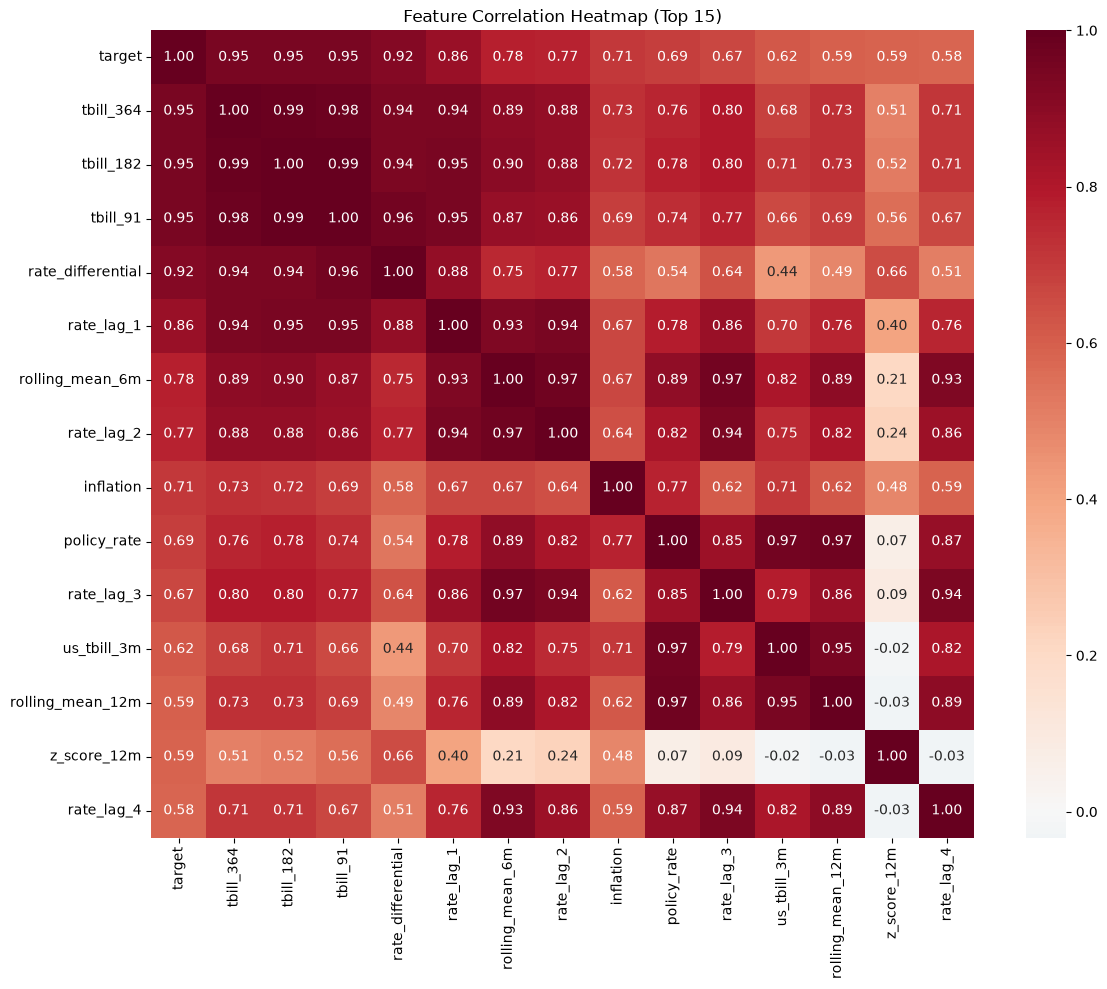

Heatmap saved!


In [8]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()['target'].sort_values(ascending=False)

print("Correlation with target (next month's 91-day rate):")
print(corr_with_target)

# Heatmap of top features
top_features = corr_with_target.head(15).index.tolist()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap (Top 15)')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

In [9]:
# ============================================================
# SAVE FINAL FEATURE DATASET
# ============================================================

# Drop rows with NaN (from lag/rolling calculations)
df_clean = df.dropna(subset=['target'])
df_clean = df_clean.dropna()

print(f"Final dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")
print(f"Features: {len(df_clean.columns) - 2}")  # minus date and target

df_clean.to_csv('../data/features_dataset.csv', index=False)
print("\nSaved to data/features_dataset.csv")

# Summary
print(f"\n{'='*50}")
print(f"FEATURE ENGINEERING SUMMARY")
print(f"{'='*50}")
print(f"Technical features: 15 (lags, momentum, rolling stats, z-score)")
print(f"Yield curve features: 4 (slope, curvature, spreads)")
print(f"Macro features: 6 (policy spread, real rate, FX, inflation)")
print(f"Regime features: 3 (volatility, rate direction, policy stance)")
print(f"Target: next month's 91-day T-bill rate")
print(f"Total observations: {len(df_clean)}")

Final dataset shape: (61, 41)
Date range: 2020-11-01 00:00:00 to 2025-11-01 00:00:00
Features: 39

Saved to data/features_dataset.csv

FEATURE ENGINEERING SUMMARY
Technical features: 15 (lags, momentum, rolling stats, z-score)
Yield curve features: 4 (slope, curvature, spreads)
Macro features: 6 (policy spread, real rate, FX, inflation)
Regime features: 3 (volatility, rate direction, policy stance)
Target: next month's 91-day T-bill rate
Total observations: 61
